In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import csv

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

# Graphics
import seaborn as sns

# Drive
from google.colab import drive

In [ ]:
# Connect Google Drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define constants

# Data file path
data_file_path = '/content/drive/MyDrive/prev-experiments/data.csv'

# Genres to analyze
genres = ['deep_house', 'tech_house', 'melodic_techno', 'progressive', 'techno_peak_time', 'hard_techno', 'minimal', 'trance']

In [ ]:
# Open data file and preprocess data

# Open CSV file
data = pd.read_csv(data_file_path)

# Drop unneccesary columns (file name)
data = data.drop(['file_name'],axis=1)

# Get last column (genre) and encode labels
genre_list = data.iloc[:, -1]
y = list(map(lambda label: genres.index(label), genre_list))

# Normalize dataset
scaler = StandardScaler()
X = scaler.fit_transform(np.array(data.iloc[:, 7:-1], dtype = float))

In [ ]:
# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
def model_acc(model):
  clf = model.fit(X_train, y_train)

  predictions = clf.predict(X_test)
  score = clf.score(X_test,y_test)

  confusion_matrix = metrics.confusion_matrix(y_test, predictions)

  plt.figure(figsize=(9,9))
  sns.heatmap(confusion_matrix, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
  plt.ylabel('Actual label');
  plt.xlabel('Predicted label');
  all_sample_title = 'Accuracy Score: {0}'.format(score)
  plt.title(all_sample_title, size = 15);

  print(metrics.classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.35      0.28      0.31        86
           1       0.45      0.56      0.50        70
           2       0.39      0.29      0.33        76
           3       0.31      0.28      0.30        79
           4       0.28      0.23      0.25        87
           5       0.37      0.43      0.40        75
           6       0.42      0.59      0.49        69
           7       0.47      0.50      0.49        98

    accuracy                           0.39       640
   macro avg       0.38      0.39      0.38       640
weighted avg       0.38      0.39      0.38       640



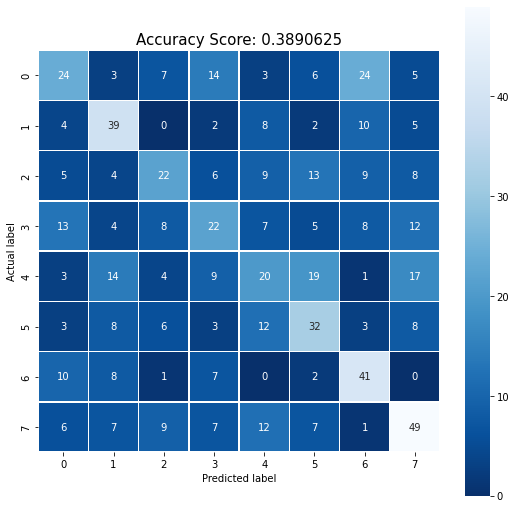

In [ ]:
# Logistic regression
logistic = LogisticRegression(multi_class='multinomial', solver='lbfgs')

model_acc(logistic)

              precision    recall  f1-score   support

           0       0.38      0.29      0.33        86
           1       0.45      0.54      0.49        70
           2       0.37      0.43      0.40        76
           3       0.40      0.39      0.39        79
           4       0.52      0.31      0.39        87
           5       0.57      0.64      0.60        75
           6       0.48      0.67      0.56        69
           7       0.57      0.53      0.55        98

    accuracy                           0.47       640
   macro avg       0.47      0.48      0.46       640
weighted avg       0.47      0.47      0.46       640



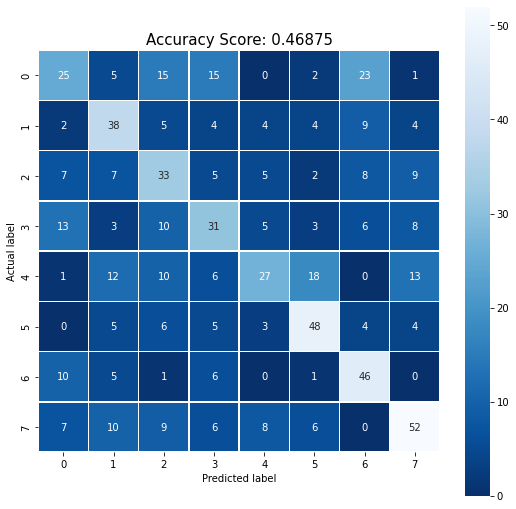

In [ ]:
# SVM

svm = SVC(decision_function_shape='ovo')

model_acc(svm)

              precision    recall  f1-score   support

           0       0.51      0.60      0.56        86
           1       0.35      0.71      0.47        70
           2       0.26      0.49      0.34        76
           3       0.44      0.30      0.36        79
           4       0.30      0.14      0.19        87
           5       0.68      0.37      0.48        75
           6       0.57      0.55      0.56        69
           7       0.60      0.33      0.42        98

    accuracy                           0.43       640
   macro avg       0.47      0.44      0.42       640
weighted avg       0.47      0.43      0.42       640



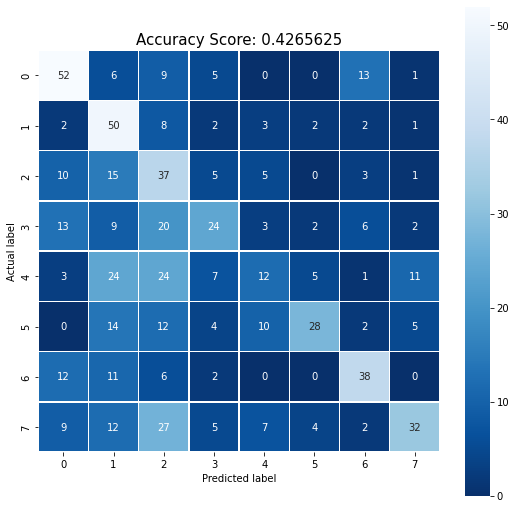

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

model_acc(knn)

              precision    recall  f1-score   support

           0       0.28      0.24      0.26        86
           1       0.34      0.36      0.35        70
           2       0.25      0.26      0.26        76
           3       0.29      0.25      0.27        79
           4       0.35      0.33      0.34        87
           5       0.39      0.39      0.39        75
           6       0.39      0.57      0.46        69
           7       0.37      0.33      0.35        98

    accuracy                           0.34       640
   macro avg       0.33      0.34      0.33       640
weighted avg       0.33      0.34      0.33       640



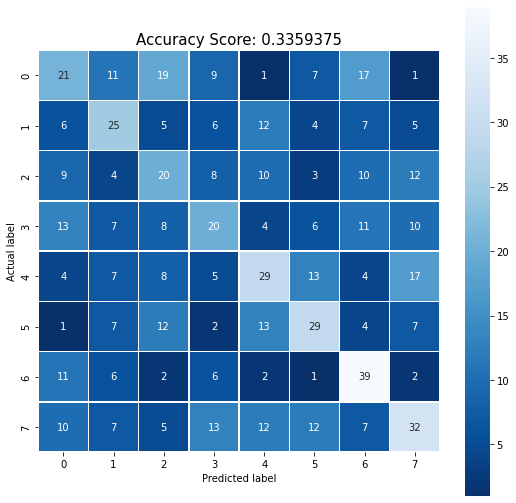

In [ ]:
tree = DecisionTreeClassifier()

model_acc(tree)

              precision    recall  f1-score   support

           0       0.25      0.24      0.25        86
           1       0.44      0.51      0.48        70
           2       0.28      0.41      0.33        76
           3       0.48      0.20      0.29        79
           4       0.42      0.06      0.10        87
           5       0.47      0.52      0.49        75
           6       0.35      0.61      0.44        69
           7       0.50      0.60      0.55        98

    accuracy                           0.39       640
   macro avg       0.40      0.39      0.37       640
weighted avg       0.40      0.39      0.36       640



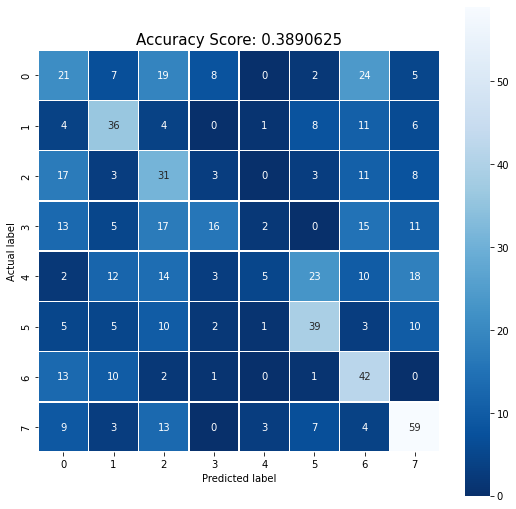

In [ ]:
forest = RandomForestClassifier(max_depth=2, random_state=0)

model_acc(forest)